-----------
Initializing structure...
time for choose_chunkdivision = 0.00169182 s
Working in 3D dimensions.
Computational cell is 50 x 17.2 x 10 with resolution 5
     cylinder, center = (0,0,0)
          radius 3.5, height 0.2, axis (0, 0, 1)
          dielectric constant epsilon diagonal = (12,12,12)
Working in 3D dimensions.
Computational cell is 50 x 17.2 x 10 with resolution 5
     cylinder, center = (0,0,0)
          radius 3.5, height 0.2, axis (0, 0, 1)
          dielectric constant epsilon diagonal = (12,12,12)
     block, center = (0,3.69,0)
          size (40,0.22,0.1)
          axes (1,0,0), (0,1,0), (0,0,1)
          dielectric constant epsilon diagonal = (12,12,12)
     block, center = (0,3.69,0)
          size (40,0.22,0.1)
          axes (1,0,0), (0,1,0), (0,0,1)
          dielectric constant epsilon diagonal = (12,12,12)
     block, center = (0,-3.69,0)
     block, center = (0,-3.69,0)
          size (40,0.22,0.1)
          axes (1,0,0), (0,1,0), (0,0,1)
          siz

MPB solved for frequency_1(0.512173,0,0) = 0.35204 after 17 iters
MPB solved for frequency_1(0.465452,0,0) = 0.31999 after 9 iters
MPB solved for frequency_1(0.465452,0,0) = 0.31999 after 9 iters
MPB solved for frequency_1(0.465466,0,0) = 0.32 after 2 iters
on time step 1 (time=0.1), 7.47632 s/step
MPB solved for frequency_1(0.465466,0,0) = 0.32 after 2 iters
on time step 1 (time=0.1), 7.47632 s/step
on time step 39 (time=3.9), 0.105943 s/step
on time step 39 (time=3.9), 0.105943 s/step
on time step 65 (time=6.5), 0.157177 s/step
on time step 65 (time=6.5), 0.157177 s/step
on time step 100 (time=10), 0.114992 s/step
on time step 100 (time=10), 0.114992 s/step
on time step 138 (time=13.8), 0.106854 s/step
on time step 138 (time=13.8), 0.106854 s/step
on time step 173 (time=17.3), 0.116676 s/step
on time step 173 (time=17.3), 0.116676 s/step
on time step 202 (time=20.2), 0.14076 s/step
on time step 202 (time=20.2), 0.14076 s/step
on time step 240 (time=24), 0.105893 s/step
on time step 2

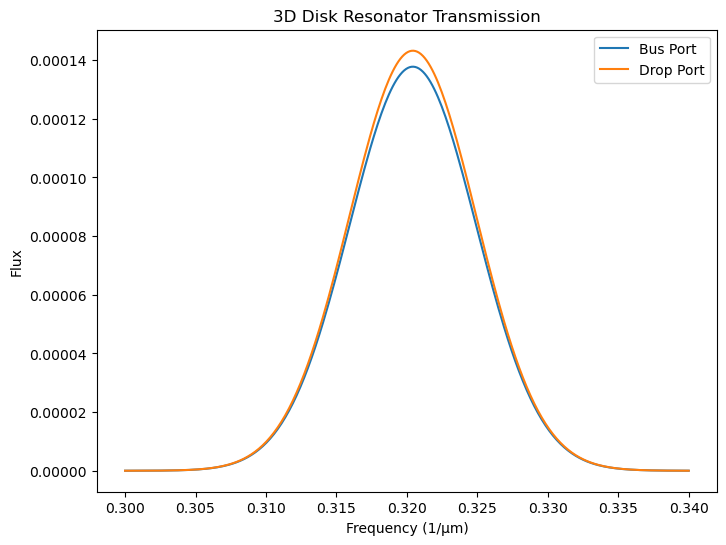

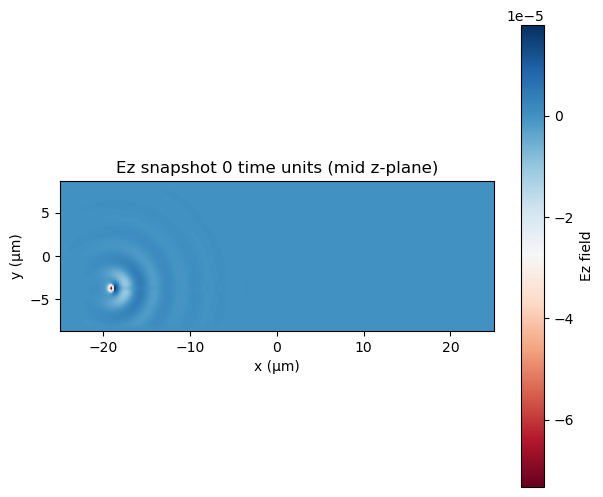

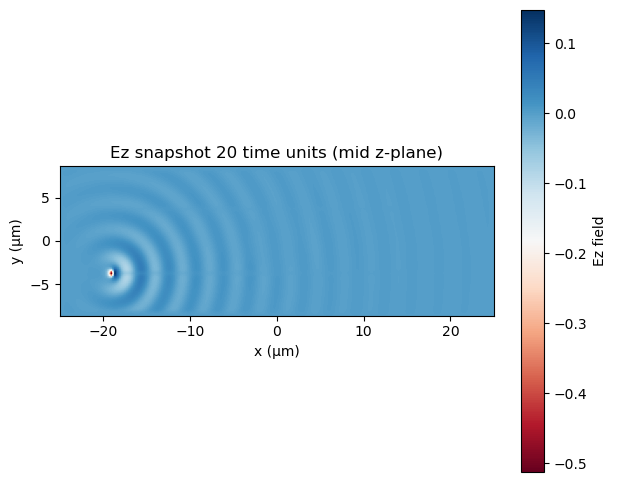

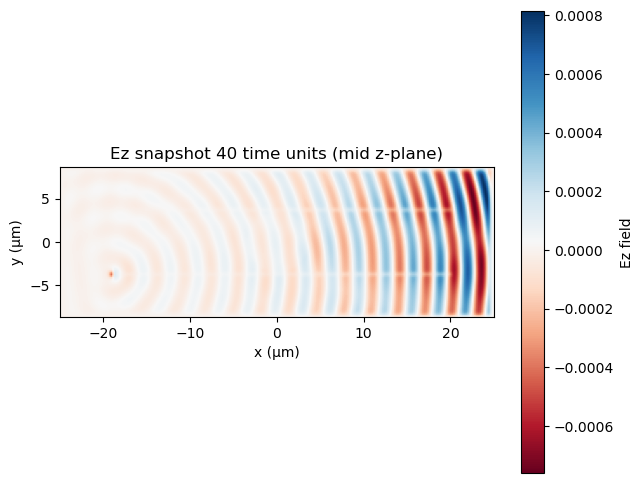

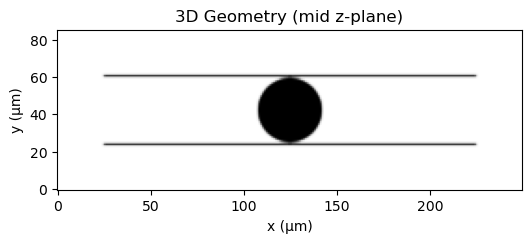

In [9]:
import meep as mp
import matplotlib.pyplot as plt
import numpy as np

# -----------------------------
# Simulation parameters
# -----------------------------
resolution = 5  # pixels/um

# Materials
gaas = mp.Medium(epsilon=12)

# Disk and waveguide geometry
disk_radius = 3.5     # um
disk_height = 0.2     # um
wg_length = 40        # um
wg_width = 0.22       # um
wg_height = 0.1       # um
gap = 0.08            # distance between disk and waveguides

# Simulation cell size (make sure divisible by resolution)
cell_x = int((wg_length + 10) * resolution) / resolution
cell_y = int((2*(disk_radius + gap + wg_width/2) + 10) * resolution) / resolution
cell_z = 10.0           # enough space above and below disk

cell = mp.Vector3(cell_x, cell_y, cell_z)

# PML layers
pml_layers = [mp.PML(1.0)]

# -----------------------------
# Geometry
# -----------------------------
geometry = [
    # Disk resonator
    mp.Cylinder(radius=disk_radius, height=disk_height, center=mp.Vector3(), material=gaas),

    # Top bus waveguide
    mp.Block(size=mp.Vector3(wg_length, wg_width, wg_height),
             center=mp.Vector3(0, disk_radius + gap + wg_width/2, 0),
             material=gaas),

    # Bottom drop waveguide
    mp.Block(size=mp.Vector3(wg_length, wg_width, wg_height),
             center=mp.Vector3(0, -disk_radius - gap - wg_width/2, 0),
             material=gaas)
]

# -----------------------------
# Source
# -----------------------------
source_x = -wg_length/2 + 1
source_y = disk_radius + gap + wg_width/2
source_z = 0

fmin = 0.3   # 1/um
fmax = 0.34
fcen = (fmin+fmax)/2
df = fmax - fmin
nfreq = 300

mode_src = mp.EigenModeSource(
    src=mp.GaussianSource(frequency=fcen, fwidth=df),
    center=mp.Vector3(source_x, source_y, source_z),
    size=mp.Vector3(0, wg_width*2, wg_height*2),  # cover waveguide cross-section
    eig_band=1,           # fundamental mode
    eig_parity=mp.NO_PARITY,   # or mp.ODD_Y/mp.EVEN_Y depending on symmetry
    eig_match_freq=True
)

sources = [mode_src]
# -----------------------------
# Flux monitors
# -----------------------------
flux_region_bus = mp.FluxRegion(center=mp.Vector3(wg_length/2 - 1, disk_radius + gap + wg_width/2, 0),
                                size=mp.Vector3(0, wg_width, wg_height))

flux_region_drop = mp.FluxRegion(center=mp.Vector3(wg_length/2 - 1, -disk_radius - gap - wg_width/2, 0),
                                 size=mp.Vector3(0, wg_width, wg_height))

# -----------------------------
# Simulation
# -----------------------------
sim = mp.Simulation(cell_size=cell,
                    geometry=geometry,
                    sources=sources,
                    boundary_layers=pml_layers,
                    resolution=resolution,
                    dimensions=3)

flux_bus = sim.add_flux(fcen, df, nfreq, flux_region_bus)
flux_drop = sim.add_flux(fcen, df, nfreq, flux_region_drop)

# -----------------------------
# Store Ez snapshots
# -----------------------------
ez_data = []

def store_fields(sim):
    ez_data.append(sim.get_array(center=mp.Vector3(), size=cell, component=mp.Ez))

# Run simulation with snapshots
sim.run(mp.at_every(20, store_fields),
        until_after_sources=mp.stop_when_fields_decayed(50, mp.Ez, mp.Vector3(0,0,0), 1e-3))

# -----------------------------
# Extract flux spectra
# -----------------------------
frequencies = np.array(mp.get_flux_freqs(flux_bus))
flux_bus_data = np.array(mp.get_fluxes(flux_bus))
flux_drop_data = np.array(mp.get_fluxes(flux_drop))

# -----------------------------
# Plot transmission spectra
# -----------------------------
plt.figure(figsize=(8,6))
plt.plot(frequencies, flux_bus_data, label="Bus Port")
plt.plot(frequencies, flux_drop_data, label="Drop Port")
plt.xlabel("Frequency (1/µm)")
plt.ylabel("Flux")
plt.title("3D Disk Resonator Transmission")
plt.legend()
plt.show()

# -----------------------------
# Plot Ez snapshots (mid z-plane)
# -----------------------------
mid_z_idx = int(cell_z/2 * resolution)  # index for mid-plane

for i, field in enumerate(ez_data[::5]):  # every 5th snapshot
    plt.figure(figsize=(7,6))
    plt.imshow(np.rot90(field[:,:,mid_z_idx]), cmap="RdBu", origin="lower",
               extent=[-cell_x/2, cell_x/2, -cell_y/2, cell_y/2])
    plt.colorbar(label="Ez field")
    plt.title(f"Ez snapshot {i*20} time units (mid z-plane)")
    plt.xlabel("x (µm)")
    plt.ylabel("y (µm)")
    plt.show()

# -----------------------------
# Plot geometry (mid z-plane)
# -----------------------------
eps = sim.get_array(center=mp.Vector3(), size=cell, component=mp.Dielectric)
plt.figure(figsize=(6,6))
plt.imshow(np.rot90(eps[:,:,mid_z_idx]), origin='lower', cmap='Greys')
plt.title("3D Geometry (mid z-plane)")
plt.xlabel("x (µm)")
plt.ylabel("y (µm)")
plt.show()


cell (x,y,z) = 50.0 17.38 4
-----------
Initializing structure...
time for choose_chunkdivision = 0.00158691 s
Working in 3D dimensions.
Computational cell is 50 x 17.375 x 4 with resolution 8
     Working in 3D dimensions.
Computational cell is 50 x 17.375 x 4 with resolution 8
     cylinder, center = (0,0,0)
          radius 3.5, height 0.2, axis (0, 0, 1)
          dielectric constant epsilon diagonal = (12,12,12)
cylinder, center = (0,0,0)
          radius 3.5, height 0.2, axis (0, 0, 1)
          dielectric constant epsilon diagonal = (12,12,12)
     block, center = (0,3.69,0)
     block, center = (0,3.69,0)
          size (40,0.22,0.1)
          axes (1,0,0), (0,1,0), (0,0,1)
          dielectric constant epsilon diagonal = (12,12,12)
          size (40,0.22,0.1)
          axes (1,0,0), (0,1,0), (0,0,1)
          dielectric constant epsilon diagonal = (12,12,12)
     block, center = (0,-3.69,0)
          size (40,0.22,0.1)
          axes (1,0,0), (0,1,0), (0,0,1)
     block, cent

MPB solved for frequency_1(1,0,0) = 0.941176 after 27 iters
MPB solved for frequency_1(0.335686,0,0) = 0.316842 after 9 iters
MPB solved for frequency_1(0.335686,0,0) = 0.316842 after 9 iters
MPB solved for frequency_1(0.339034,0,0) = 0.32 after 5 iters
MPB solved for frequency_1(0.339034,0,0) = 0.32 after 5 iters
MPB solved for frequency_1(0.339034,0,0) = 0.32 after 1 iters
MPB solved for frequency_1(0.339034,0,0) = 0.32 after 1 iters


FloatProgress(value=0.0, description='0% done ', max=200.0)

Meep progress: 0.0625/200.0 = 0.0% done in 7.2s, 22998.9s to go
on time step 1 (time=0.0625), 7.17517 s/step
Meep progress: 2.0625/200.0 = 1.0% done in 11.3s, 1079.7s to go
on time step 33 (time=2.0625), 0.126882 s/step
Meep progress: 2.0625/200.0 = 1.0% done in 11.3s, 1079.7s to go
on time step 33 (time=2.0625), 0.126882 s/step
Meep progress: 4.0/200.0 = 2.0% done in 15.3s, 747.5s to go
on time step 64 (time=4), 0.129126 s/step
Meep progress: 4.0/200.0 = 2.0% done in 15.3s, 747.5s to go
on time step 64 (time=4), 0.129126 s/step
Meep progress: 6.0/200.0 = 3.0% done in 19.3s, 624.4s to go
on time step 96 (time=6), 0.126754 s/step
Meep progress: 6.0/200.0 = 3.0% done in 19.3s, 624.4s to go
on time step 96 (time=6), 0.126754 s/step
Meep progress: 8.0/200.0 = 4.0% done in 23.4s, 561.6s to go
on time step 128 (time=8), 0.127771 s/step
Meep progress: 8.0/200.0 = 4.0% done in 23.4s, 561.6s to go
on time step 128 (time=8), 0.127771 s/step
Meep progress: 10.0625/200.0 = 5.0% done in 27.5s, 518.

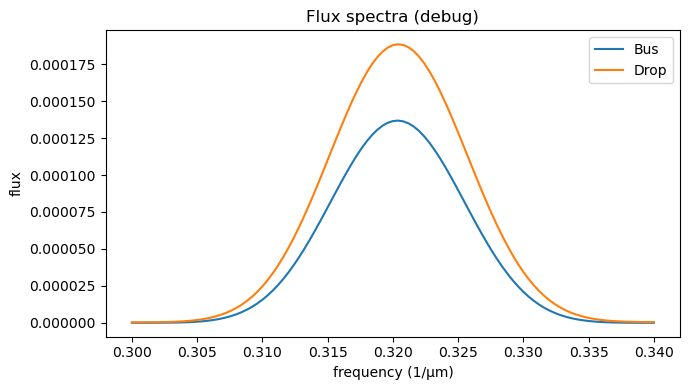

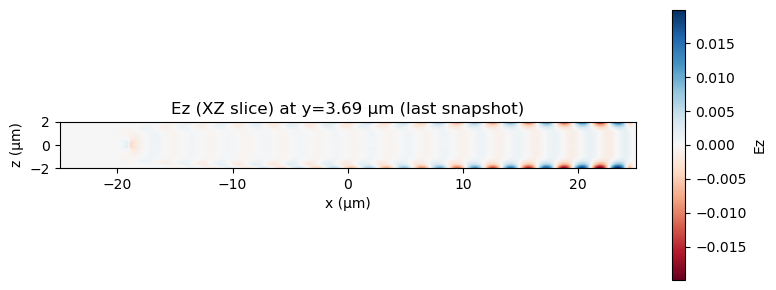

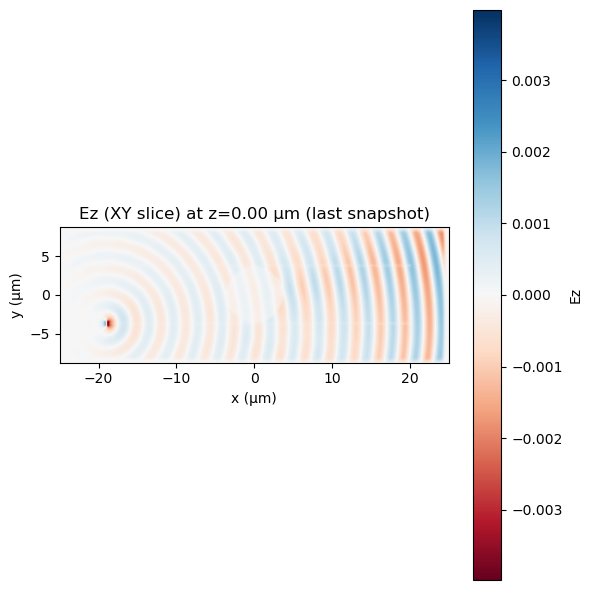

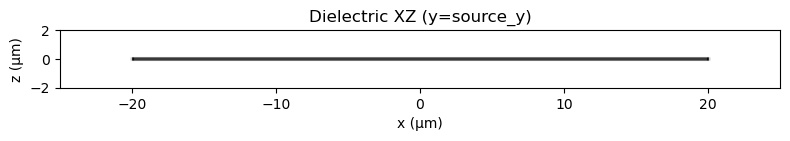

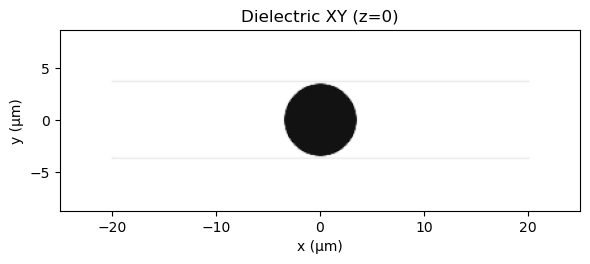

In [16]:

# -----------------------------
# Revised simulation parameters
# -----------------------------
resolution = 8  # px/um (increase for accuracy; lower to 10 if memory is tight)

# Materials
gaas = mp.Medium(epsilon=12.0)

# Disk and waveguide geometry (same as yours)
disk_radius = 3.5     # um
disk_height = 0.2     # um
wg_length = 40.0      # um
wg_width = 0.22       # um (y direction)
wg_height = 0.10      # um (z direction)
gap = 0.08            # distance between disk and waveguides

# Simulation cell (make z small so mode is resolved)
cell_x = (wg_length + 10.0)   # keep it simple (no int-rounding trick)
cell_y = 2*(disk_radius + gap + wg_width/2) + 10.0
cell_z = 4   # much smaller than your original 10.0 -> helps resolve vertical structure
cell = mp.Vector3(cell_x, cell_y, cell_z)

print("cell (x,y,z) =", cell_x, cell_y, cell_z)

# PML layers (1.0 um is fine if cell dims >> pml)
pml_layers = [mp.PML(1.0)]

# -----------------------------
# Geometry
# -----------------------------
geometry = [
    mp.Cylinder(radius=disk_radius, height=disk_height, center=mp.Vector3(0,0,0), material=gaas),
    mp.Block(size=mp.Vector3(wg_length, wg_width, wg_height),
             center=mp.Vector3(0, disk_radius + gap + wg_width/2, 0),
             material=gaas),
    mp.Block(size=mp.Vector3(wg_length, wg_width, wg_height),
             center=mp.Vector3(0, -disk_radius - gap - wg_width/2, 0),
             material=gaas)
]

# -----------------------------
# Source (EigenModeSource) - explicit kpoint & small x extent
# -----------------------------
source_x = -wg_length/2 + 1.0
source_y = disk_radius + gap + wg_width/2
source_z = 0.0

fmin = 0.30   # 1/um
fmax = 0.34
fcen = 0.5*(fmin + fmax)
df = fmax - fmin
nfreq = 101   # fewer bins for debugging

mode_src = mp.EigenModeSource(
    src=mp.GaussianSource(frequency=fcen, fwidth=df),
    center=mp.Vector3(source_x, source_y, source_z),
    size=mp.Vector3(0.2, wg_width*3.0, wg_height*3.0),  # small x extent, larger y/z to capture tails
    direction=mp.X,                                     # launch along +X (waveguide axis)
    eig_kpoint=mp.Vector3(1.0, 0, 0),                   # k-point for mode solver along x
    eig_band=1,
    eig_parity=mp.NO_PARITY,
    eig_match_freq=True
)
sources = [mode_src]

# -----------------------------
# Flux monitors (small cross-section)
# -----------------------------
flux_region_bus = mp.FluxRegion(center=mp.Vector3(wg_length/2 - 1.0, disk_radius + gap + wg_width/2, 0),
                                size=mp.Vector3(0, wg_width*2.0, wg_height*2.0))
flux_region_drop = mp.FluxRegion(center=mp.Vector3(wg_length/2 - 1.0, -disk_radius - gap - wg_width/2, 0),
                                 size=mp.Vector3(0, wg_width*2.0, wg_height*2.0))

# -----------------------------
# Simulation
# -----------------------------
sim = mp.Simulation(cell_size=cell,
                    geometry=geometry,
                    sources=sources,
                    boundary_layers=pml_layers,
                    resolution=resolution,
                    dimensions=3)

flux_bus = sim.add_flux(fcen, df, nfreq, flux_region_bus)
flux_drop = sim.add_flux(fcen, df, nfreq, flux_region_drop)

# -----------------------------
# Store both XZ slice (side view) and XY slice (top view)
# -----------------------------
xz_slices = []
xy_slices = []

ny_index_y = source_y     # y coordinate for XZ slice
nz_index_z = 0.0          # z coordinate for XY slice (center of waveguide plane)

def store_slices(sim):
    # --- XZ slice at fixed y ---
    arr_xz = sim.get_array(center=mp.Vector3(0.0, source_y, 0.0),
                           size=mp.Vector3(cell_x, 0.0, cell_z),
                           component=mp.Ez)
    xz_slices.append(arr_xz)

    # --- XY slice at fixed z ---
    arr_xy = sim.get_array(center=mp.Vector3(0.0, 0.0, nz_index_z),
                           size=mp.Vector3(cell_x, cell_y, 0.0),
                           component=mp.Ez)
    xy_slices.append(arr_xy)

# run a finite time
sim.run(mp.at_every(20, store_slices), until=200)


# -----------------------------
# Flux spectra
# -----------------------------
freqs = np.array(mp.get_flux_freqs(flux_bus))
flux_bus_data = np.array(mp.get_fluxes(flux_bus))
flux_drop_data = np.array(mp.get_fluxes(flux_drop))

plt.figure(figsize=(7,4))
plt.plot(freqs, flux_bus_data, label='Bus')
plt.plot(freqs, flux_drop_data, label='Drop')
plt.xlabel('frequency (1/µm)')
plt.ylabel('flux')
plt.legend()
plt.title('Flux spectra (debug)')
plt.tight_layout()
plt.show()

# -----------------------------
# Show last XZ slice (Ez) at y = source_y
# -----------------------------
if len(xz_slices) == 0:
    print("No slices stored.")
else:
    last = xz_slices[-1]
    # last shape: (nx, nz)
    nx, nz = last.shape
    extent = [-cell_x/2, cell_x/2, -cell_z/2, cell_z/2]
    plt.figure(figsize=(8,3))
    plt.imshow(np.rot90(last), origin='lower', extent=extent, cmap='RdBu',
               vmin=-np.max(np.abs(last)), vmax=np.max(np.abs(last)))
    plt.colorbar(label='Ez')
    plt.xlabel('x (µm)')
    plt.ylabel('z (µm)')
    plt.title(f'Ez (XZ slice) at y={source_y:.2f} µm (last snapshot)')
    plt.tight_layout()
    plt.show()

if len(xy_slices) > 0:
    last_xy = xy_slices[-1]
    ny, nx = last_xy.shape
    extent_xy = [-cell_x/2, cell_x/2, -cell_y/2, cell_y/2]
    plt.figure(figsize=(6,6))
    plt.imshow(np.rot90(last_xy), origin='lower', extent=extent_xy, cmap='RdBu',
               vmin=-np.max(np.abs(last_xy)), vmax=np.max(np.abs(last_xy)))
    plt.colorbar(label='Ez')
    plt.xlabel('x (µm)')
    plt.ylabel('y (µm)')
    plt.title(f'Ez (XY slice) at z={nz_index_z:.2f} µm (last snapshot)')
    plt.tight_layout()
    plt.show()

# -----------------------------
# Quick dielectric XZ cross-section for reference
# -----------------------------
eps = sim.get_array(component=mp.Dielectric, center=mp.Vector3(0.0, source_y, 0.0),
                    size=mp.Vector3(cell_x, 0.0, cell_z))
plt.figure(figsize=(8,3))
plt.imshow(np.rot90(eps), origin='lower', extent=extent, cmap='Greys')
plt.xlabel('x (µm)')
plt.ylabel('z (µm)')
plt.title('Dielectric XZ (y=source_y)')
plt.tight_layout()
plt.show()

eps_xy = sim.get_array(component=mp.Dielectric,
                       center=mp.Vector3(0.0, 0.0, nz_index_z),
                       size=mp.Vector3(cell_x, cell_y, 0.0))
plt.figure(figsize=(6,6))
plt.imshow(np.rot90(eps_xy), origin='lower', extent=extent_xy, cmap='Greys')
plt.xlabel('x (µm)')
plt.ylabel('y (µm)')
plt.title('Dielectric XY (z=0)')
plt.tight_layout()
plt.show()



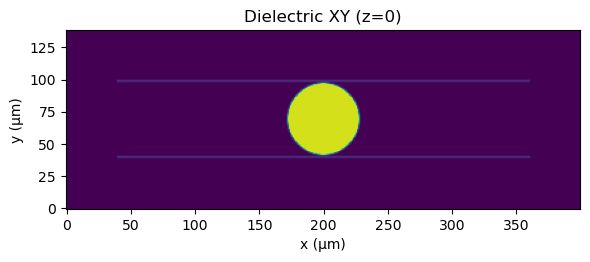

In [ ]:
eps_xy = sim.get_array(component=mp.Dielectric,
                       center=mp.Vector3(0.0, 0.0, -0.05),
                       size=mp.Vector3(cell_x, cell_y, 0.0))
plt.figure(figsize=(6,6))
plt.imshow(np.rot90(eps_xy), origin='lower', extent=extent_xy)
plt.xlabel('x (µm)')
plt.ylabel('y (µm)')
plt.title('Dielectric XY (z=0)')
plt.tight_layout()
plt.show()